In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
np.random.seed(42)
n = 200
data = pd.DataFrame({
    "experience": np.random.randint(0,15,n),
    "education_years": np.random.randint(10,20,n),
    "age":np.random.randint(22,60,n)

})
data["salary"]=(
    30000 +
    data["experience"]*4000 +
    data["education_years"]*2000 +
    data["age"]*500 +
    np.random.randn(n) *10000
)
data.head()

,experience,education_years,age,salary
0,6,14,54,94519.156585
1,3,16,30,74925.362256
2,12,16,50,127815.557787
3,14,13,47,133365.528483
4,10,16,56,133109.075656


In [8]:
print(data.shape)
print(data.info())
print(data.describe())

(200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   experience       200 non-null    int64  
 1   education_years  200 non-null    int64  
 2   age              200 non-null    int64  
 3   salary           200 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 6.4 KB
None
       experience  education_years         age         salary
count  200.000000       200.000000  200.000000     200.000000
mean     7.450000        14.030000   41.480000  107930.770318
std      4.320978         2.872343   10.794545   21625.242870
min      0.000000        10.000000   22.000000   51912.605136
25%      4.000000        12.000000   33.000000   92845.365487
50%      7.500000        14.000000   43.000000  109920.880152
75%     11.000000        16.250000   51.000000  124549.757680
max     14.000000        19.000000   59.000000  161814.58765

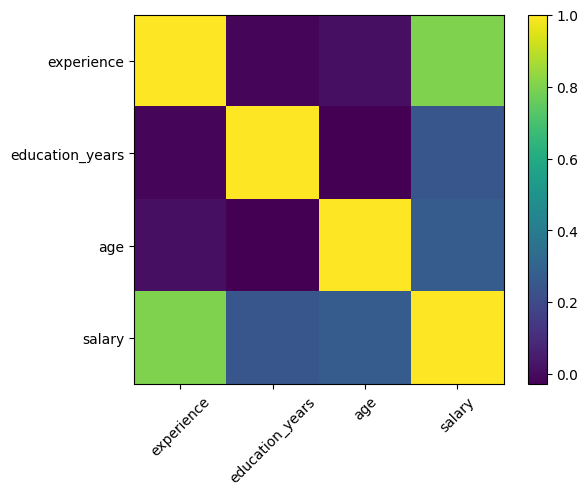

In [10]:
corr = data.corr()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.show()

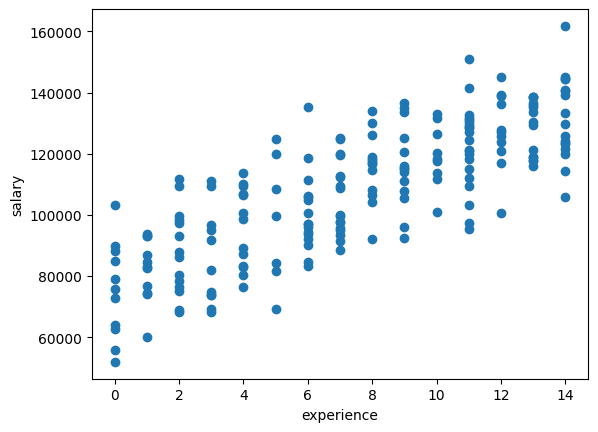

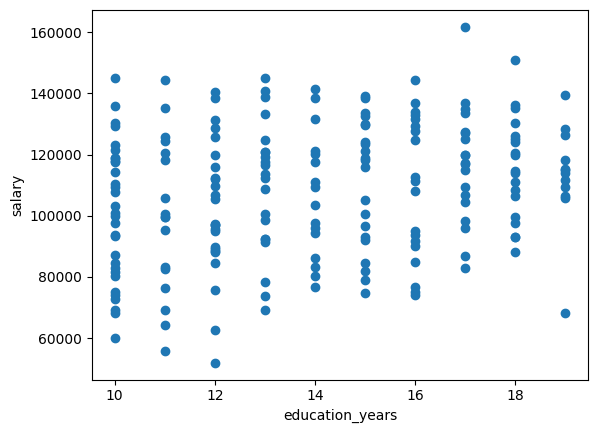

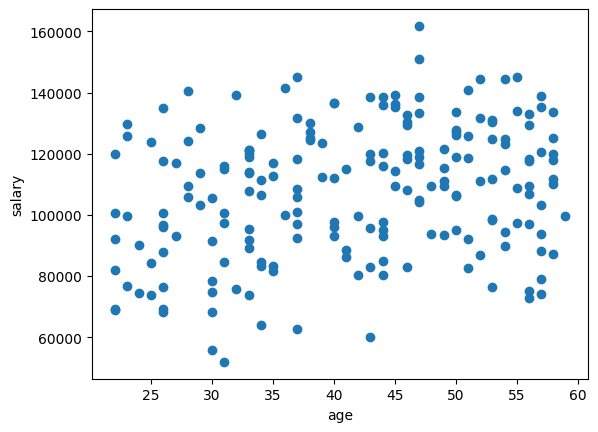

In [11]:
features=["experience","education_years","age"]

for col in features:
  plt.figure()
  plt.scatter(data[col],data["salary"])
  plt.xlabel(col)
  plt.ylabel("salary")
  plt.show()

In [16]:
x = data[["experience","education_years","age"]]
y = data["salary"]

In [17]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2, random_state=42
    )

In [18]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

y=b0+ b1x1 + b2x2 +b3x3 +....+ bnxn :
in our coditon :
salary = b0 + coeficient * experence (1)+coe(2) * edu_year + coe(3)* age

In [19]:
print(model.coef_)
print(model.intercept_)

[4010.01266984 2140.39750127  498.99071873]
27089.505470418415


In [24]:
y_pred = model.predict(x_test)

In [25]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print(mse,rmse,r2)

115720573.59072885 10757.349747532096 0.7957078323644551


In [32]:
new_data = pd.DataFrame({
    "experience": [5],
    "education_years": [16],
    "age": [30]
})

print(model.predict(new_data))

[96355.65040184]
